# Boxing Dominance Model

This notebook creates a quantitative dominance ranking for the 75 selected professional boxers.

The model combines several aspects of career dominance:

- Overall winning ability
- Knockout ability
- Championship success
- Championship fight performance
- Career longevity

The metrics are normalised before weighting so that statistics measured on different scales can be compared fairly.

Alternative weighting systems were also tested to determine how sensitive the rankings are to different definitions of dominance.

## 1. Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [9]:
df = pd.read_csv("../data/boxing_final_75.csv")

df.head()

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses
0,Archie Moore,Light Heavyweight to Heavyweight,186,23,10,1,220,186-23-10 (132 KOs),132,60.0,7,1935,1935-1963,World Light Heavyweight,8995,71.0,29.0,10,2
1,Sugar Ray Robinson,Welterweight to Middleweight,174,19,6,2,201,174-19-6 (109 KOs),109,54.2,1,1940,1940-1965,World Welterweight/Middleweight,9625,62.6,37.4,14,7
2,Muhammad Ali,Heavyweight,56,5,0,0,61,56-5 (37 KOs),37,60.7,1,1960,1960-1981,WBA/WBC Heavyweight,180,66.1,33.9,22,3
3,Joe Louis,Heavyweight,66,3,0,0,69,66-3 (52 KOs),52,75.4,2,1934,1934-1951,World Heavyweight,9027,78.8,21.2,27,1
4,Ezzard Charles,Middleweight to Heavyweight,95,25,1,0,121,95-25-1 (52 KOs),52,43.0,7,1940,1940-1959,NBA Heavyweight,9012,54.7,45.3,9,4


In [10]:
df.shape

(75, 19)

## 3. Prepare Data for Modelling

The transformations required by the dominance model are recreated here so that this notebook can run independently from the exploration notebook.

"Present" in Years Active is replaced with 2026, allowing career length to be calculated numerically.

In [11]:
df["Years Active"] = df["Years Active"].str.replace(
    "Present",
    "2026",
    regex=False
)

In [12]:
df["Years Active"] = df["Years Active"].str.replace(
    "Present",
    "2026",
    regex=False
)

In [13]:
career_years = df["Years Active"].str.split(
    "-",
    expand=True
)

df["Career Length"] = (
    pd.to_numeric(career_years[1])
    - pd.to_numeric(career_years[0])
)

In [14]:
df["Win %"] = (
    df["Wins"]
    / df["Total Fights"]
    * 100
)

In [15]:
df["Loss %"] = (
    df["Losses"]
    / df["Total Fights"]
    * 100
)

In [16]:
df["Title Fight Total"] = (
    df["Title Fight Wins"]
    + df["Title Fight Losses"]
)

In [17]:
df["Title Fight Win %"] = np.where(
    df["Title Fight Total"] > 0,
    (
        df["Title Fight Wins"]
        / df["Title Fight Total"]
        * 100
    ),
    0
)

In [18]:
df[
    [
        "Fighter Name",
        "Win %",
        "KO %",
        "Title Fight Wins",
        "Title Fight Win %",
        "Career Length"
    ]
].head(10)

,Fighter Name,Win %,KO %,Title Fight Wins,Title Fight Win %,Career Length
0,Archie Moore,84.545455,60.0,10,83.333333,28
1,Sugar Ray Robinson,86.567164,54.2,14,66.666667,25
2,Muhammad Ali,91.803279,60.7,22,88.000000,21
3,Joe Louis,95.652174,75.4,27,96.428571,17
4,Ezzard Charles,78.512397,43.0,9,69.230769,19
5,Harry Greb,87.290970,16.4,5,71.428571,13
6,Carlos Monzon,87.000000,59.0,15,100.000000,14
7,Tony Canzoneri,80.571429,25.1,12,57.142857,14
8,Dick Tiger,73.170732,32.9,6,66.666667,18
9,Carlos Ortiz,87.142857,42.9,14,77.777778,17


## 4. Select Dominance Metrics

The baseline model uses five metrics:

- **Win %** — measures overall success across a fighter's career.
- **KO %** — measures the proportion of total fights won by knockout.
- **Title Fight Wins** — measures championship-level success and sustained performance at the highest level.
- **Title Fight Win %** — measures how successful a fighter was when competing in title fights.
- **Career Length** — gives a small reward for maintaining an elite professional career over a longer period.

Some available statistics are deliberately excluded from the baseline model.

**Loss %** is excluded because it overlaps strongly with Win %.

**Decision Win %** is excluded because winning a larger proportion of fights by decision does not necessarily represent greater dominance.

**Stoppage Win %** is excluded because it is closely related to KO %, and including both could give finishing ability too much influence over the final score.

In [19]:
metrics = [
    "Win %",
    "KO %",
    "Title Fight Wins",
    "Title Fight Win %",
    "Career Length"
]

df[metrics].describe()

,Win %,KO %,Title Fight Wins,Title Fight Win %,Career Length
count,75.000000,75.000000,75.000000,75.000000,75.000000
mean,87.856020,56.134667,13.186667,80.631700,18.573333
std,8.188032,18.685234,7.238585,17.099314,6.153824
min,66.878981,8.700000,0.000000,0.000000,8.000000
25%,82.301607,43.500000,8.000000,71.428571,14.000000
50%,87.290970,58.700000,12.000000,83.333333,17.000000
75%,93.257576,71.900000,17.500000,90.909091,22.500000
max,100.000000,90.900000,31.000000,100.000000,34.000000


## 5. Inspect Metric Relationships

Before combining the metrics, their relationships are examined.

Strong correlations may indicate that two metrics measure similar aspects of fighter performance.

In [20]:
df[metrics].corr()

,Win %,KO %,Title Fight Wins,Title Fight Win %,Career Length
Win %,1.000000,0.659821,0.032737,0.603288,-0.318800
KO %,0.659821,1.000000,0.162458,0.460636,-0.106522
Title Fight Wins,0.032737,0.162458,1.000000,0.403860,0.372224
Title Fight Win %,0.603288,0.460636,0.403860,1.000000,-0.134683
Career Length,-0.318800,-0.106522,0.372224,-0.134683,1.000000


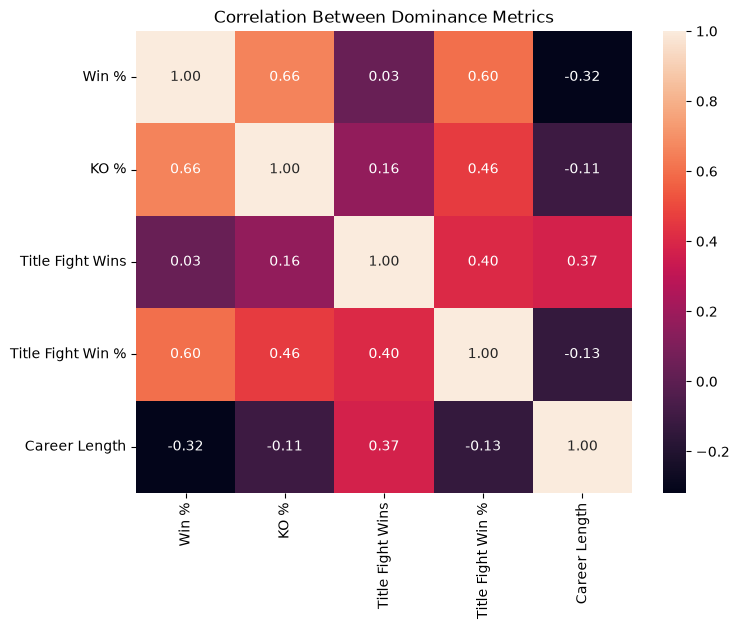

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[metrics].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Dominance Metrics")

plt.show()

## 6. Normalise Metrics

The selected metrics use different scales.

For example, Win % is measured from 0 to 100, while Title Fight Wins is a count.

Min-max normalisation converts every metric to a value between 0 and 1:

**Normalised Value = (Value - Minimum) / (Maximum - Minimum)**

This allows the metrics to be combined without statistics with naturally larger numerical values automatically dominating the score.

In [24]:
def min_max_normalise(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )

In [26]:
df["Win % Norm"] = min_max_normalise(
    df["Win %"]
)

df["KO % Norm"] = min_max_normalise(
    df["KO %"]
)

df["Title Fight Wins Norm"] = min_max_normalise(
    df["Title Fight Wins"]
)

df["Title Fight Win % Norm"] = min_max_normalise(
    df["Title Fight Win %"]
)

df["Career Length Norm"] = min_max_normalise(
    df["Career Length"]
)

In [28]:
normalised_metrics = [
    "Win % Norm",
    "KO % Norm",
    "Title Fight Wins Norm",
    "Title Fight Win % Norm",
    "Career Length Norm"
]

df[
    ["Fighter Name"] + normalised_metrics
].head(10)

,Fighter Name,Win % Norm,KO % Norm,Title Fight Wins Norm,Title Fight Win % Norm,Career Length Norm
0,Archie Moore,0.533392,0.624088,0.322581,0.833333,0.769231
1,Sugar Ray Robinson,0.594432,0.553528,0.451613,0.666667,0.653846
2,Muhammad Ali,0.752522,0.632603,0.709677,0.880000,0.500000
3,Joe Louis,0.868729,0.811436,0.870968,0.964286,0.346154
4,Ezzard Charles,0.351240,0.417275,0.290323,0.692308,0.423077
5,Harry Greb,0.616285,0.093674,0.161290,0.714286,0.192308
6,Carlos Monzon,0.607500,0.611922,0.483871,1.000000,0.230769
7,Tony Canzoneri,0.413407,0.199513,0.387097,0.571429,0.230769
8,Dick Tiger,0.189962,0.294404,0.193548,0.666667,0.384615
9,Carlos Ortiz,0.611813,0.416058,0.451613,0.777778,0.346154


In [29]:
df[normalised_metrics].describe()

,Win % Norm,KO % Norm,Title Fight Wins Norm,Title Fight Win % Norm,Career Length Norm
count,75.000000,75.000000,75.000000,75.000000,75.000000
mean,0.633345,0.577064,0.425376,0.806317,0.406667
std,0.247216,0.227314,0.233503,0.170993,0.236686
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.465645,0.423358,0.258065,0.714286,0.230769
50%,0.616285,0.608273,0.387097,0.833333,0.346154
75%,0.796431,0.768856,0.564516,0.909091,0.557692
max,1.000000,1.000000,1.000000,1.000000,1.000000


## 7. Define Baseline Weights

The baseline model places the greatest emphasis on overall winning ability while also rewarding finishing ability, championship success, title-fight performance, and longevity.

The weights are:

- Win %: **35%**
- KO %: **20%**
- Title Fight Wins: **20%**
- Title Fight Win %: **15%**
- Career Length: **10%**

The weights sum to 100%.

These weights represent one possible definition of boxing dominance rather than an objective universal definition. Alternative weighting systems will therefore be tested later.

In [30]:
baseline_weights = {
    "Win % Norm": 0.35,
    "KO % Norm": 0.20,
    "Title Fight Wins Norm": 0.20,
    "Title Fight Win % Norm": 0.15,
    "Career Length Norm": 0.10
}

In [31]:
sum(baseline_weights.values())

1.0

## 8. Calculate Baseline Dominance Score

Each normalised metric is multiplied by its assigned weight.

The weighted values are added together and multiplied by 100 to produce a Dominance Score out of 100.

In [32]:
df["Dominance Score"] = (
    df["Win % Norm"]
    * baseline_weights["Win % Norm"]

    + df["KO % Norm"]
    * baseline_weights["KO % Norm"]

    + df["Title Fight Wins Norm"]
    * baseline_weights["Title Fight Wins Norm"]

    + df["Title Fight Win % Norm"]
    * baseline_weights["Title Fight Win % Norm"]

    + df["Career Length Norm"]
    * baseline_weights["Career Length Norm"]
) * 100

In [33]:
df["Dominance Rank"] = (
    df["Dominance Score"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

In [34]:
df["Dominance Score"] = (
    df["Dominance Score"]
    .round(2)
)

## 9. Baseline Ranking

In [35]:
baseline_ranking = df.sort_values(
    "Dominance Rank"
)

In [36]:
baseline_ranking[
    [
        "Dominance Rank",
        "Fighter Name",
        "Dominance Score",
        "Win %",
        "KO %",
        "Title Fight Wins",
        "Title Fight Win %",
        "Career Length"
    ]
].head(20)

,Dominance Rank,Fighter Name,Dominance Score,Win %,KO %,Title Fight Wins,Title Fight Win %,Career Length
57,1,Naoya Inoue,86.87,100.000000,81.8,26,100.000000,14
33,2,Julio Cesar Chavez,83.56,93.043478,74.8,31,88.571429,25
50,3,Floyd Mayweather,82.80,100.000000,54.0,26,100.000000,21
55,4,Terence Crawford,82.20,100.000000,73.8,20,100.000000,17
3,5,Joe Louis,81.98,95.652174,75.4,27,96.428571,17
59,6,Oleksandr Usyk,74.41,100.000000,64.0,14,100.000000,13
15,7,Rocky Marciano,73.76,100.000000,87.8,7,100.000000,8
69,8,Jermall Charlo,73.34,100.000000,67.6,8,100.000000,18
61,9,Gennadiy Golovkin,73.30,93.333333,82.2,17,89.473684,16
47,10,Alexis Arguello,73.20,90.588235,72.9,19,86.363636,27


## 10. Metric Contributions

The final score can be broken down into its individual components.

This makes the model easier to interpret by showing why each fighter received their final dominance score.

In [37]:
df["Win Contribution"] = (
    df["Win % Norm"]
    * baseline_weights["Win % Norm"]
    * 100
)

df["KO Contribution"] = (
    df["KO % Norm"]
    * baseline_weights["KO % Norm"]
    * 100
)

df["Title Wins Contribution"] = (
    df["Title Fight Wins Norm"]
    * baseline_weights["Title Fight Wins Norm"]
    * 100
)

df["Title Win Rate Contribution"] = (
    df["Title Fight Win % Norm"]
    * baseline_weights["Title Fight Win % Norm"]
    * 100
)

df["Longevity Contribution"] = (
    df["Career Length Norm"]
    * baseline_weights["Career Length Norm"]
    * 100
)

In [38]:
df.sort_values(
    "Dominance Rank"
)[
    [
        "Fighter Name",
        "Dominance Score",
        "Win Contribution",
        "KO Contribution",
        "Title Wins Contribution",
        "Title Win Rate Contribution",
        "Longevity Contribution"
    ]
].head(10)

,Fighter Name,Dominance Score,Win Contribution,KO Contribution,Title Wins Contribution,Title Win Rate Contribution,Longevity Contribution
57,Naoya Inoue,86.87,35.000000,17.785888,16.774194,15.000000,2.307692
33,Julio Cesar Chavez,83.56,27.648829,16.082725,20.000000,13.285714,6.538462
50,Floyd Mayweather,82.80,35.000000,11.021898,16.774194,15.000000,5.000000
55,Terence Crawford,82.20,35.000000,15.839416,12.903226,15.000000,3.461538
3,Joe Louis,81.98,30.405518,16.228710,17.419355,14.464286,3.461538
59,Oleksandr Usyk,74.41,35.000000,13.454988,9.032258,15.000000,1.923077
15,Rocky Marciano,73.76,35.000000,19.245742,4.516129,15.000000,0.000000
69,Jermall Charlo,73.34,35.000000,14.330900,5.161290,15.000000,3.846154
61,Gennadiy Golovkin,73.30,27.955128,17.883212,10.967742,13.421053,3.076923
47,Alexis Arguello,73.20,25.054299,15.620438,12.258065,12.954545,7.307692


## 11. Visualise Baseline Rankings

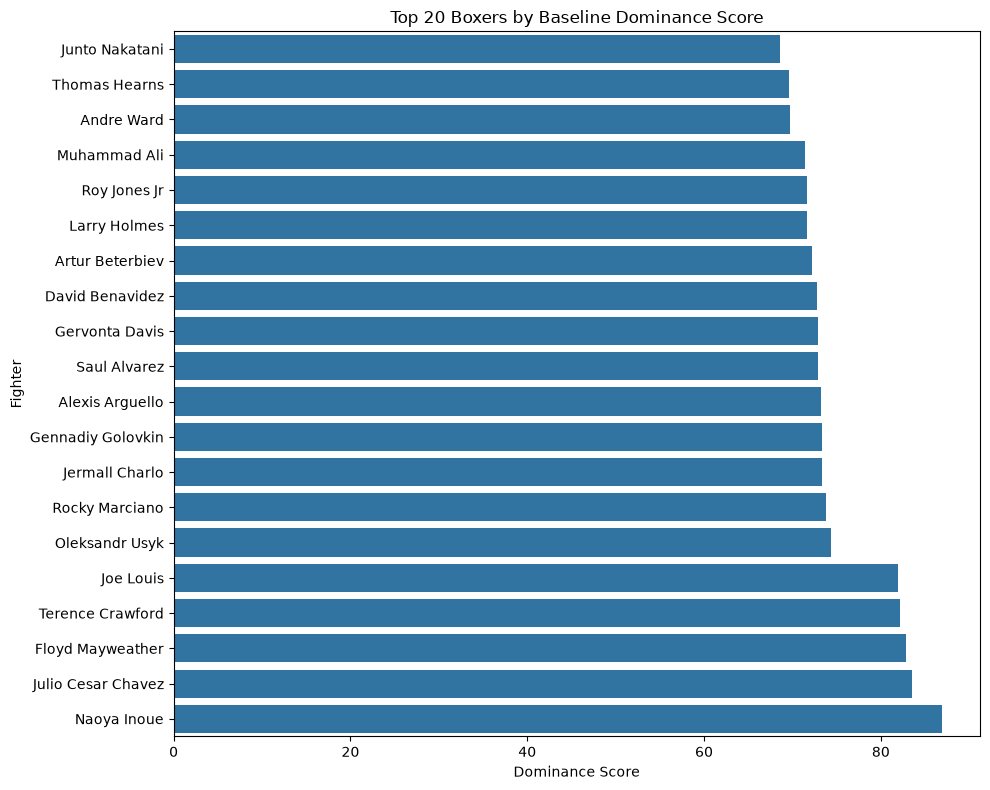

In [39]:
top_20 = (
    df.nsmallest(
        20,
        "Dominance Rank"
    )
    .sort_values(
        "Dominance Score",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_20,
    x="Dominance Score",
    y="Fighter Name"
)

plt.title("Top 20 Boxers by Baseline Dominance Score")
plt.xlabel("Dominance Score")
plt.ylabel("Fighter")

plt.tight_layout()

plt.savefig(
    "../charts/top_20_dominance.png",
    bbox_inches="tight"
)

plt.show()

## 12. Visualise Score Composition

The contribution of each metric can be compared for the Top 10 fighters.

This shows whether a fighter's ranking is driven mainly by winning percentage, knockout ability, championship achievements, title-fight efficiency, or longevity.

In [40]:
top_10 = (
    df.nsmallest(
        10,
        "Dominance Rank"
    )
    .sort_values(
        "Dominance Score",
        ascending=True
    )
    .set_index("Fighter Name")
)

contribution_columns = [
    "Win Contribution",
    "KO Contribution",
    "Title Wins Contribution",
    "Title Win Rate Contribution",
    "Longevity Contribution"
]

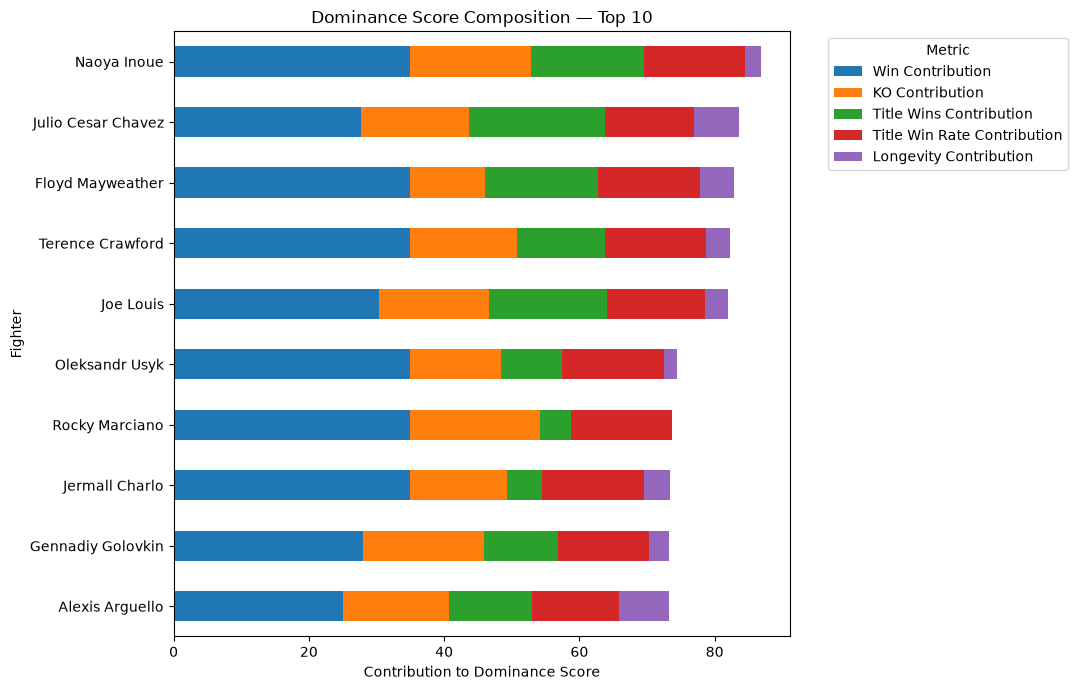

In [41]:
top_10[contribution_columns].plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7)
)

plt.title("Dominance Score Composition — Top 10")
plt.xlabel("Contribution to Dominance Score")
plt.ylabel("Fighter")

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../charts/top_10_score_composition.png",
    bbox_inches="tight"
)

plt.show()

## 13. Sensitivity Analysis

The weights used in the baseline model are subjective.

To test how dependent the rankings are on these choices, two alternative definitions of dominance are examined:

### Finisher-Heavy Model

Places greater importance on knockout ability.

### Championship-Heavy Model

Places greater importance on the number of title-fight victories.

Comparing these models shows which fighters remain highly ranked regardless of how dominance is defined.

In [42]:
finisher_weights = {
    "Win % Norm": 0.30,
    "KO % Norm": 0.30,
    "Title Fight Wins Norm": 0.15,
    "Title Fight Win % Norm": 0.15,
    "Career Length Norm": 0.10
}

sum(finisher_weights.values())

1.0

In [43]:
df["Finisher Score"] = (
    df["Win % Norm"]
    * finisher_weights["Win % Norm"]

    + df["KO % Norm"]
    * finisher_weights["KO % Norm"]

    + df["Title Fight Wins Norm"]
    * finisher_weights["Title Fight Wins Norm"]

    + df["Title Fight Win % Norm"]
    * finisher_weights["Title Fight Win % Norm"]

    + df["Career Length Norm"]
    * finisher_weights["Career Length Norm"]
) * 100

In [44]:
df["Finisher Rank"] = (
    df["Finisher Score"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

df["Finisher Score"] = (
    df["Finisher Score"]
    .round(2)
)

In [45]:
championship_weights = {
    "Win % Norm": 0.30,
    "KO % Norm": 0.15,
    "Title Fight Wins Norm": 0.30,
    "Title Fight Win % Norm": 0.15,
    "Career Length Norm": 0.10
}

sum(championship_weights.values())

1.0

In [46]:
df["Championship Score"] = (
    df["Win % Norm"]
    * championship_weights["Win % Norm"]

    + df["KO % Norm"]
    * championship_weights["KO % Norm"]

    + df["Title Fight Wins Norm"]
    * championship_weights["Title Fight Wins Norm"]

    + df["Title Fight Win % Norm"]
    * championship_weights["Title Fight Win % Norm"]

    + df["Career Length Norm"]
    * championship_weights["Career Length Norm"]
) * 100

In [47]:
df["Championship Rank"] = (
    df["Championship Score"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

df["Championship Score"] = (
    df["Championship Score"]
    .round(2)
)

## 14. Compare Ranking Models

The three models can now be compared directly.

A fighter who remains highly ranked under all three definitions has a more robust claim to dominance than a fighter whose position changes dramatically depending on the weighting system.

In [48]:
comparison = df[
    [
        "Fighter Name",
        "Dominance Rank",
        "Finisher Rank",
        "Championship Rank"
    ]
].copy()

In [49]:
comparison["Average Rank"] = (
    comparison[
        [
            "Dominance Rank",
            "Finisher Rank",
            "Championship Rank"
        ]
    ]
    .mean(axis=1)
    .round(2)
)

In [50]:
comparison.sort_values(
    "Average Rank"
).head(20)

,Fighter Name,Dominance Rank,Finisher Rank,Championship Rank,Average Rank
57,Naoya Inoue,1,1,1,1.00
33,Julio Cesar Chavez,2,2,2,2.00
50,Floyd Mayweather,3,5,3,3.67
55,Terence Crawford,4,3,5,4.00
3,Joe Louis,5,4,4,4.33
15,Rocky Marciano,7,6,16,9.67
47,Alexis Arguello,10,11,8,9.67
59,Oleksandr Usyk,6,13,11,10.00
61,Gennadiy Golovkin,9,10,12,10.33
56,Saul Alvarez,11,16,6,11.00


## 15. Ranking Stability

Ranking stability measures how much a fighter's position changes across the three models.

The best and worst ranking achieved by each fighter are identified.

The difference between these values is called the Rank Range.

A small Rank Range indicates that the fighter's position is relatively stable across different suggested definitions of dominance.

In [51]:
rank_columns = [
    "Dominance Rank",
    "Finisher Rank",
    "Championship Rank"
]

comparison["Best Rank"] = (
    comparison[rank_columns]
    .min(axis=1)
)

comparison["Worst Rank"] = (
    comparison[rank_columns]
    .max(axis=1)
)

comparison["Rank Range"] = (
    comparison["Worst Rank"]
    - comparison["Best Rank"]
)

In [52]:
comparison.sort_values(
    [
        "Average Rank",
        "Rank Range"
    ]
).head(20)

,Fighter Name,Dominance Rank,Finisher Rank,Championship Rank,Average Rank,Best Rank,Worst Rank,Rank Range
57,Naoya Inoue,1,1,1,1.00,1,1,0
33,Julio Cesar Chavez,2,2,2,2.00,2,2,0
50,Floyd Mayweather,3,5,3,3.67,3,5,2
55,Terence Crawford,4,3,5,4.00,3,5,2
3,Joe Louis,5,4,4,4.33,4,5,1
47,Alexis Arguello,10,11,8,9.67,8,11,3
15,Rocky Marciano,7,6,16,9.67,6,16,10
59,Oleksandr Usyk,6,13,11,10.00,6,13,7
61,Gennadiy Golovkin,9,10,12,10.33,9,12,3
69,Jermall Charlo,8,12,13,11.00,8,13,5


In [53]:
comparison.sort_values(
    "Rank Range",
    ascending=False
).head(15)

,Fighter Name,Dominance Rank,Finisher Rank,Championship Rank,Average Rank,Best Rank,Worst Rank,Rank Range
48,George Foreman,23,14,34,23.67,14,34,20
22,Harry Wills,42,47,29,39.33,29,47,18
54,Bernard Hopkins,34,42,24,33.33,24,42,18
11,Henry Armstrong,41,46,31,39.33,31,46,15
42,Sonny Liston,51,45,60,52.00,45,60,15
49,Pernell Whitaker,49,54,39,47.33,39,54,15
65,Errol Spence Jr,31,25,40,32.00,25,40,15
71,David Benavidez,13,9,22,14.67,9,22,13
66,Anthony Joshua,45,36,49,43.33,36,49,13
64,Gervonta Davis,12,7,20,13.00,7,20,13


## 16. Visualise Ranking Stability

The Top 15 fighters by average ranking are compared across all three dominance models.

In [54]:
top_15_stable = (
    comparison
    .sort_values("Average Rank")
    .head(15)
    .set_index("Fighter Name")
)

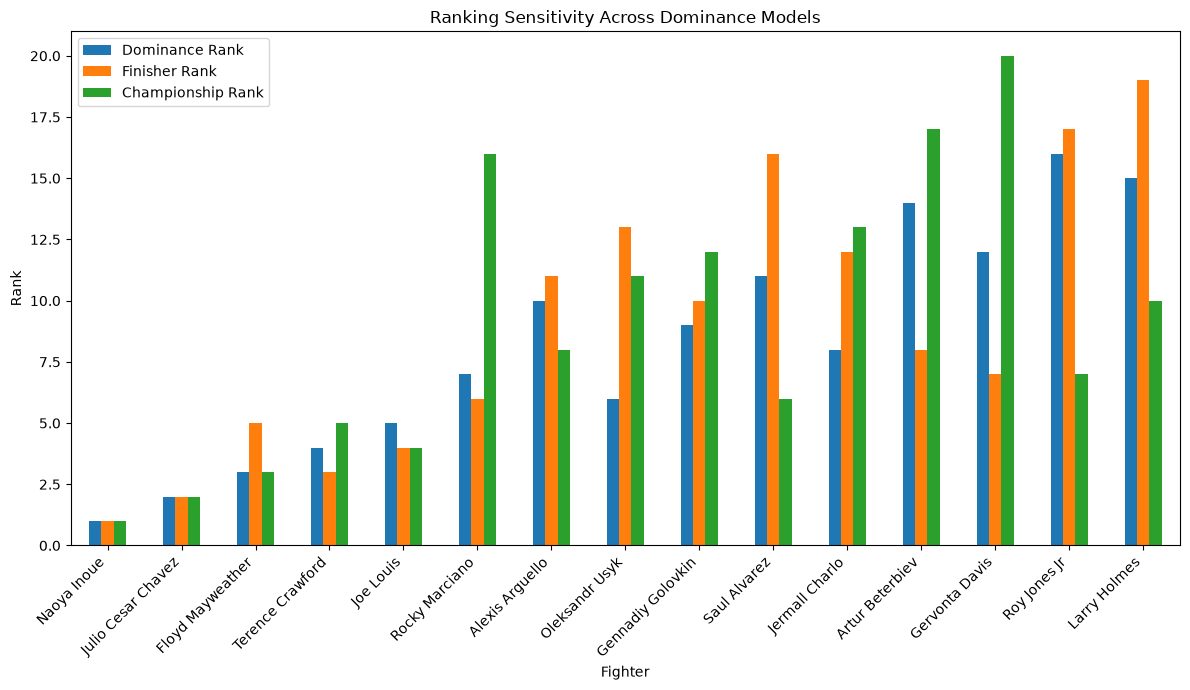

In [55]:
top_15_stable[
    [
        "Dominance Rank",
        "Finisher Rank",
        "Championship Rank"
    ]
].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Ranking Sensitivity Across Dominance Models")
plt.xlabel("Fighter")
plt.ylabel("Rank")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "../charts/ranking_sensitivity.png",
    bbox_inches="tight"
)

plt.show()

## 17. Final Baseline Ranking

The baseline model is retained as the primary ranking.

The alternative models are used as sensitivity tests rather than replacements for the baseline definition of dominance.

In [56]:
final_ranking = (
    df.sort_values(
        "Dominance Rank"
    )[
        [
            "Dominance Rank",
            "Fighter Name",
            "Dominance Score",
            "Win %",
            "KO %",
            "Title Fight Wins",
            "Title Fight Win %",
            "Career Length"
        ]
    ]
)

final_ranking.head(25)

,Dominance Rank,Fighter Name,Dominance Score,Win %,KO %,Title Fight Wins,Title Fight Win %,Career Length
57,1,Naoya Inoue,86.87,100.000000,81.8,26,100.000000,14
33,2,Julio Cesar Chavez,83.56,93.043478,74.8,31,88.571429,25
50,3,Floyd Mayweather,82.80,100.000000,54.0,26,100.000000,21
55,4,Terence Crawford,82.20,100.000000,73.8,20,100.000000,17
3,5,Joe Louis,81.98,95.652174,75.4,27,96.428571,17
59,6,Oleksandr Usyk,74.41,100.000000,64.0,14,100.000000,13
15,7,Rocky Marciano,73.76,100.000000,87.8,7,100.000000,8
69,8,Jermall Charlo,73.34,100.000000,67.6,8,100.000000,18
61,9,Gennadiy Golovkin,73.30,93.333333,82.2,17,89.473684,16
47,10,Alexis Arguello,73.20,90.588235,72.9,19,86.363636,27


In [57]:
final_ranking

,Dominance Rank,Fighter Name,Dominance Score,Win %,KO %,Title Fight Wins,Title Fight Win %,Career Length
57,1,Naoya Inoue,86.87,100.000000,81.8,26,100.000000,14
33,2,Julio Cesar Chavez,83.56,93.043478,74.8,31,88.571429,25
50,3,Floyd Mayweather,82.80,100.000000,54.0,26,100.000000,21
55,4,Terence Crawford,82.20,100.000000,73.8,20,100.000000,17
3,5,Joe Louis,81.98,95.652174,75.4,27,96.428571,17
...,...,...,...,...,...,...,...,...
8,71,Dick Tiger,30.25,73.170732,32.9,6,66.666667,18
12,72,Jimmy McLarnin,28.05,79.710145,30.4,2,40.000000,13
20,73,Jack Britton,22.90,68.695652,8.7,7,63.636364,26
30,74,Carmen Basilio,22.41,70.886076,34.2,5,45.454545,13


## 18. Save Results

In [58]:
final_ranking.to_csv(
    "../data/boxing_dominance_rankings.csv",
    index=False
)

In [59]:
comparison.to_csv(
    "../data/ranking_sensitivity.csv",
    index=False
)

## 19. Model Limitations

This dominance model provides a structured way to compare fighters, but it has several limitations.

Historical boxing eras differ significantly in the number of fights, championship structures, weight divisions, and opportunities available to fighters.

Title-fight statistics are therefore not perfectly comparable across every era.

Career Length rewards longevity, but a longer career does not automatically mean a more dominant career. For this reason, longevity receives only a relatively small weight.

The selected weights are subjective and represent one interpretation of dominance. Sensitivity analysis is used to show how the rankings change when greater importance is placed on different aspects of performance.

The dataset also does not contain detailed punch-by-punch performance statistics for all historical fighters, so the model focuses on career-level statistics that can be compared across the full sample.